In [1]:
import json
import os
import sys
from pathlib import Path
from typing import Tuple

import grid2op
import networkx as nx
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# Add project root to Python path
project_root = Path.cwd().parent.parent  # Adjusts for notebook being in src/visualization/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.experiments.utils import edge_index_to_graph, expected_distance
from src.common.observation_space import BusConnectivityGraphObsSpace, EDGE_INDEX
from src.visualization.evaluate_edge_consistency import compute_edge_statistics, load_and_stack
from src.visualization.utils import visualize_graph, PlottingArgs, get_node_styles
from src.nri.utils import fully_connected_edge_index

sns.reset_orig()

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Edge-type consistency analysis across NRI sessions

This notebook loads edge-type probability predictions from multiple NRI training sessions,
computes consistency metrics, and visualizes results. It groups sessions by file prefixes
and, where there is strong consensus on the predicted edge type across sessions, it visualizes
the corresponding edges using `visualization.utils.visualize_graph`.

Data directory (relative to repo root): `data/edge_probabilities/`

Session groups (prefixes):
- `edges_testing_NRI_with_forecast`
- `edges_training_NRI_with_forecast`

Metrics overview (computed per edge across sessions):
- Mean and standard deviation of type probabilities (over sessions).
- Coefficient of variation (CV = std/mean), NaN when mean=0.
- Entropy of the mean distribution per edge; and mean entropy within sessions.
- Agreement fraction of argmax type across sessions; Fleiss' kappa overall.
- Mean pairwise Jensen–Shannon divergence across sessions (per edge) and session×session heatmap.

Visualization of consensus edges: If the agreement fraction for an edge is above a threshold,
the edge is considered to be in consensus and shown with the most agreed-upon type. Type 0 (often "no-edge")
can be skipped when rendering.


## Configure prefixes, thresholds, and output directories
You can adjust the agreement threshold (default 0.90) and whether to skip the first edge type (typically the "no-edge" class).


In [2]:
plt.rcParams.update({
    "font.size": 14,          # base font
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

data_dir = Path('../../results/edge_probabilities')
prefixes = [
    'edges_testing_NRI_with_forecast',
    #'edges_training_NRI_with_forecast',
]

no_interaction_index = 0  # index of the "no-edge" type in the K edge types; typically 0 but adjust if your data differs
env = grid2op.make("l2rpn_case14_sandbox")
powerline_edge_index = BusConnectivityGraphObsSpace(env.observation_space).to_gym(env.reset())[EDGE_INDEX]
N = np.max(powerline_edge_index) + 1
all_edges = fully_connected_edge_index(num_nodes=N)
powergrid_graph = edge_index_to_graph(powerline_edge_index)
src, dst = powerline_edge_index

# compute path lengths with dijkstra
path_length = dict(nx.all_pairs_dijkstra_path_length(powergrid_graph))

# Output base directory for figures and CSVs generated by analysis code
out_base = Path('output/edge_consistency_notebook')
os.makedirs(out_base, exist_ok=True)

## Run analysis for each session group
For each prefix, we load all matching .npy files, stack them into shape (S, E, K), and compute summary metrics.


In [3]:
edge_statistics = {}
for prefix in prefixes:
    print(f'=== Analyzing prefix: {prefix} ===')
    # Load and analyze
    stacked, files = load_and_stack(data_dir, prefix, no_interaction_index=no_interaction_index)
    stats = compute_edge_statistics(stacked)
    edge_statistics[prefix] = stats
    # Show basic summary
    S, E, K = stacked.shape
    summary = {
        'n_sessions': int(S),
        'n_edges': int(E),
        'n_types': int(K),
        'kappa_overall': float(stats['kappa_overall']) if stats['kappa_overall'] is not None else None,
        'mean_js_over_edges': float(np.nanmean(stats['js_per_edge'])),
        'median_js_over_edges': float(np.nanmedian(stats['js_per_edge'])),
    }
    print("Summary: " + json.dumps(summary, indent=2))

print('Analysis complete.')

=== Analyzing prefix: edges_testing_NRI_with_forecast ===
Summary: {
  "n_sessions": 10,
  "n_edges": 3192,
  "n_types": 2,
  "kappa_overall": 0.4707511508000692,
  "mean_js_over_edges": 0.14356736028692232,
  "median_js_over_edges": 0.10903285136015037
}
Analysis complete.


# Examine single predicted graph
We visualize the latent edges for the first session in the stacked array, showing both the histogram of edge existence probabilities and the graph visualization with latent edges.

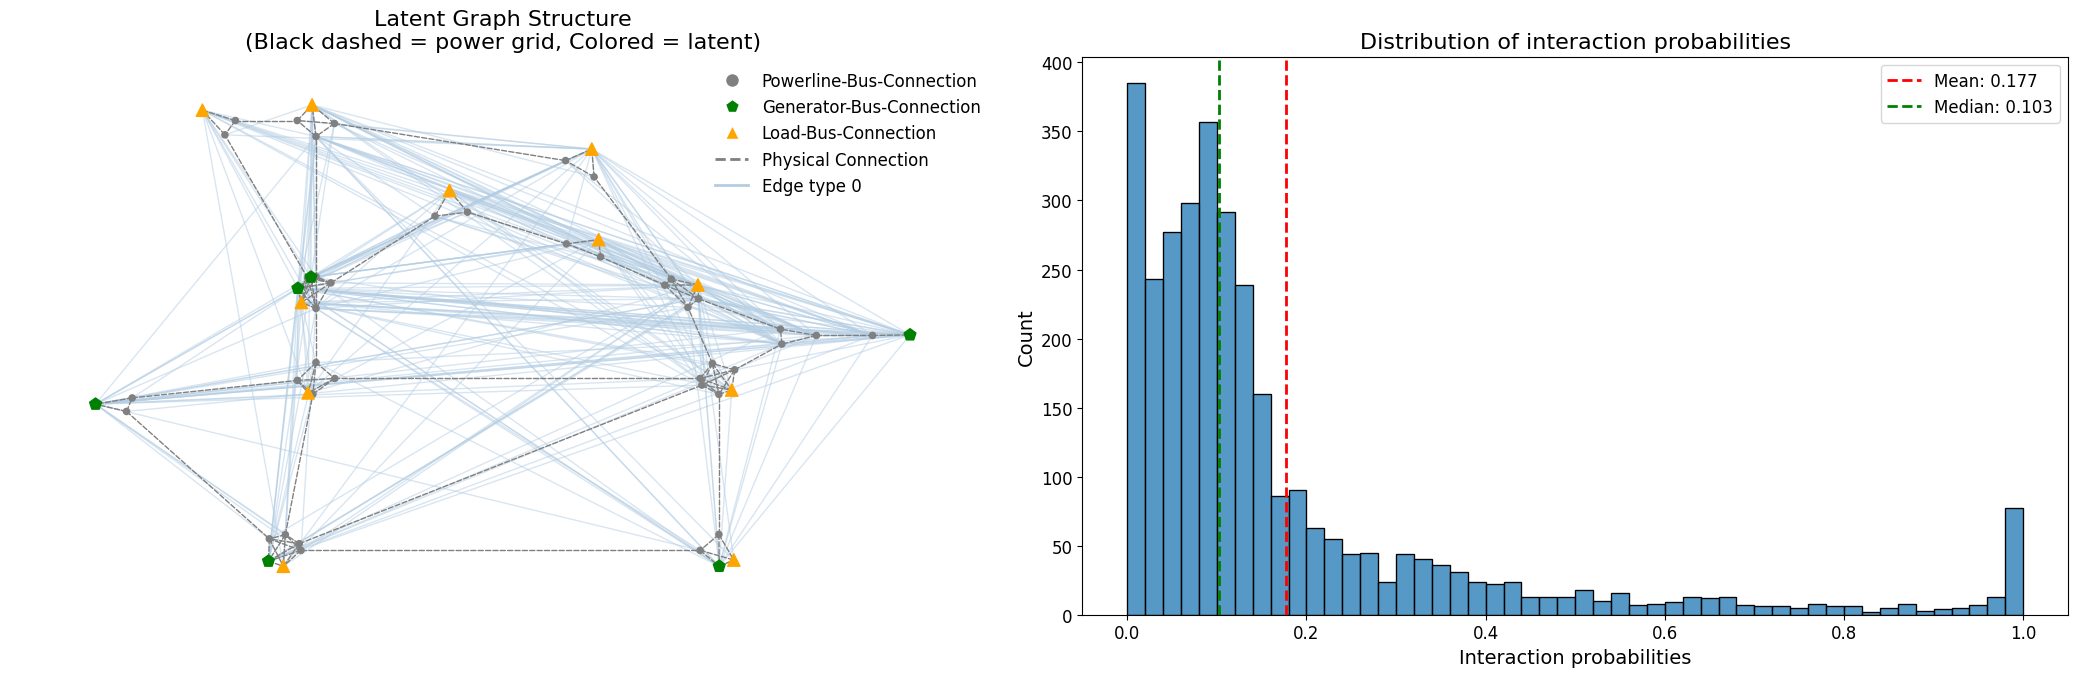

Expected edit distance between latent graph and power grid graph: 723.78


In [5]:
def draw_pg_with_latent_probs(posterior: np.ndarray, show: bool = True) -> Tuple[Figure, Axes]:
    edge_probs = posterior[:, 0]  # Edge existence probabilities

    fig, axes = plt.subplots(1, 2, figsize=(21, 7))

    # Left: Histogram
    sns.histplot(edge_probs, bins=50, ax=axes[1])
    axes[1].axvline(edge_probs.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {edge_probs.mean():.3f}')
    axes[1].axvline(np.median(edge_probs), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(edge_probs):.3f}')
    axes[1].set_xlabel('Interaction probabilities')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Distribution of interaction probabilities')
    axes[1].legend()

    # Right: Graph visualization
    visualize_graph(PlottingArgs(
        num_nodes=N,
        node_styles=get_node_styles(env=env, observation_space=BusConnectivityGraphObsSpace),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=posterior,
        latent_edge_weight=1.0,
        skip_last_edge_type=True
    ), ax=axes[0])
    axes[0].set_title('Latent Graph Structure\n(Black dashed = power grid, Colored = latent)')

    plt.tight_layout()
    if show:
        plt.show()

    return fig, axes


for prefix in prefixes:
    stacked, files = load_and_stack(data_dir, prefix, no_interaction_index=no_interaction_index)
    posterior = stacked[0]
    _ = draw_pg_with_latent_probs(posterior)
    plt.close()
    expected_edit_distance = expected_distance(posterior=posterior, all_edges=all_edges, reference_graph=powergrid_graph, n=50)
    print(f"Expected edit distance between latent graph and power grid graph:", expected_edit_distance)

## Metric explanations
- **Mean probabilities (per edge, per type):** Average of the predicted type probabilities across sessions.
- **Standard deviation (per edge, per type):** Spread of predicted probabilities across sessions.
- **Coefficient of variation (CV):** std/mean; larger values suggest higher relative variability.
- **Entropy of mean distribution:** Entropy (base 2) of the mean type distribution per edge; higher means less certainty.
- **Mean within-session entropy:** Average entropy across sessions for each edge; captures noisiness per session.
- **Agreement fraction:** Fraction of sessions that selected the same argmax type for an edge (1.0 means full agreement).
- **Fleiss' kappa (overall):** Agreement beyond chance over all edges and sessions; 0≈chance, >0 better than chance.
- **Per-edge JS divergence:** Mean pairwise Jensen–Shannon divergence across sessions for each edge; higher means less consistent.


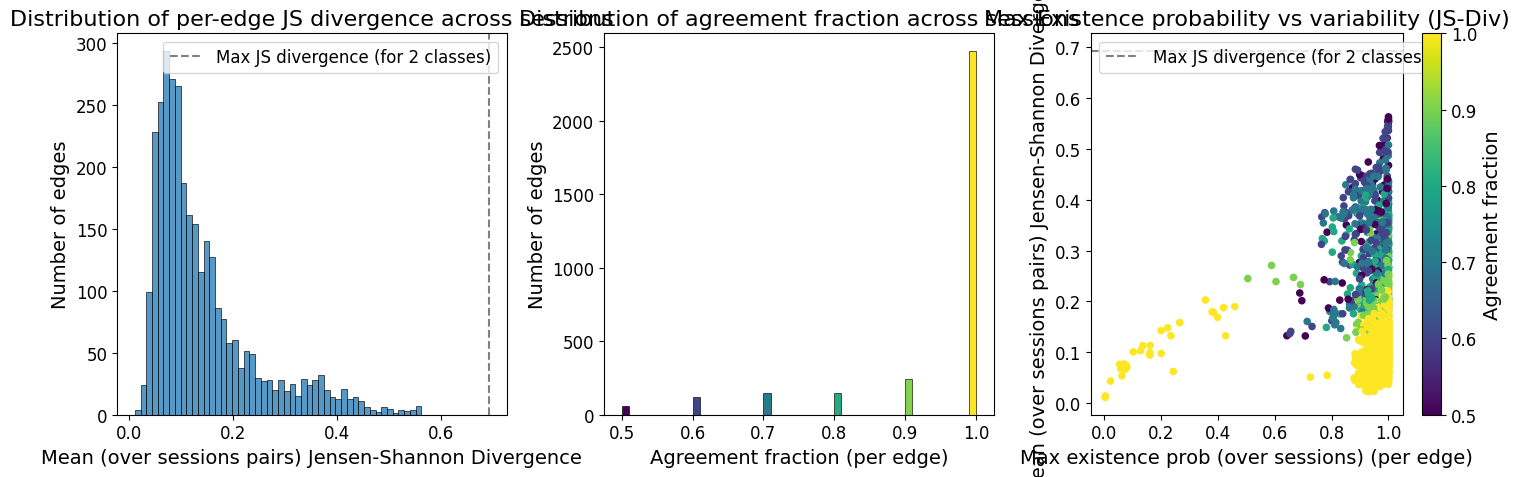

In [5]:
from matplotlib.colors import Normalize

for prefix in prefixes:
    stats = edge_statistics[prefix]
    out_dir = Path(os.path.join(out_base, prefix))
    os.makedirs(out_dir, exist_ok=True)
    # draw
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # 1. mean pairwise js div
    sns.histplot(stats['js_per_edge'], bins=50, ax=axes[0])
    axes[0].set_xlabel('Mean (over sessions pairs) Jensen-Shannon Divergence')
    axes[0].set_ylabel('Number of edges')
    axes[0].set_title('Distribution of per-edge JS divergence across sessions')
    axes[0].axvline(0.6931, color='gray', linestyle='--', label='Max JS divergence (for 2 classes)')
    axes[0].legend(loc='upper right')
    # 2. agreement fraction
    cmap = plt.cm.viridis
    norm = Normalize(vmin=stats['agreement_fraction'].min(), vmax=stats['agreement_fraction'].max())
    colors = cmap(norm(stats['agreement_fraction']))

    sns.histplot(
        stats['agreement_fraction'],
        bins=50,
        ax=axes[1],
        element="bars",
    )
    for patch, val in zip(axes[1].patches, np.linspace(stats['agreement_fraction'].min(), stats['agreement_fraction'].max(), len(axes[1].patches))):
        patch.set_facecolor(cmap(norm(val)))

    axes[1].set_xlabel('Agreement fraction (per edge)')
    axes[1].set_ylabel('Number of edges')
    axes[1].set_title('Distribution of agreement fraction across sessions')
    # 3. Max Existence probability vs variability (JS-Div)
    sc = axes[2].scatter(stats['max_exists_probs'], stats['js_per_edge'], c=stats['agreement_fraction'], cmap="viridis", s=20)
    axes[2].set_xlabel('Max existence prob (over sessions) (per edge)')
    axes[2].set_ylabel('Mean (over sessions pairs) Jensen-Shannon Divergence')
    axes[2].set_title('Max Existence probability vs variability (JS-Div)')
    axes[2].axhline(0.6931, color='gray', linestyle='--', label='Max JS divergence (for 2 classes)')
    axes[2].legend(loc="upper left")
    cbar = plt.colorbar(sc, ax=axes[2], label='Agreement fraction')
    fig.tight_layout()

    fig.savefig(Path(out_dir, "consensus_summary.png"))
    plt.show()

## Visualize edges with strong consensus
We mark an edge as "consensus" when its agreement fraction ≥ the threshold above.
For visualization, we build a latent edge-probabilities array of shape (E, K): for consensus edges,
we keep the mean probability on the consensus type and set others to zero; for non-consensus edges, we set all zeros.

Rendering uses `visualization.utils.visualize_graph`. If the number of edges E matches a fully-connected directed graph
on N nodes (E = N·(N−1)), we infer N and render a graph using a circular fallback layout (unless you provide node styles).
Note: If repository dependencies like `grid2op` are not installed, graph rendering might be skipped—install requirements
to enable full visualization.


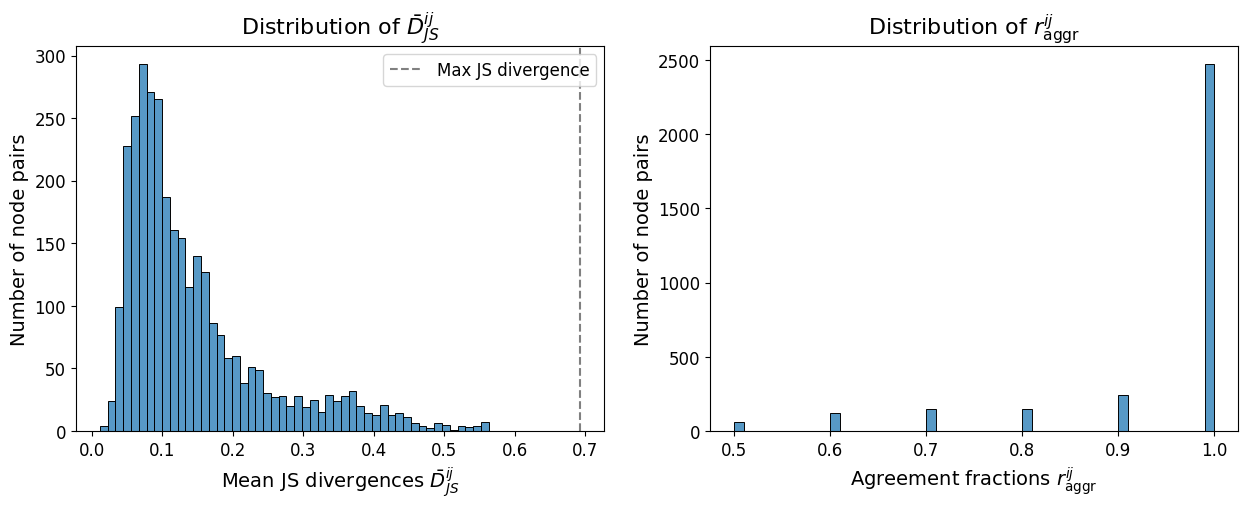

In [168]:
for prefix in prefixes:
    stats = edge_statistics[prefix]
    out_dir = Path(os.path.join(out_base, prefix))
    os.makedirs(out_dir, exist_ok=True)
    # draw
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    # 1. mean pairwise js div
    sns.histplot(stats['js_per_edge'], bins=50, ax=axes[0])
    axes[0].set_xlabel(r'$\text{Mean JS divergences } \bar{D}_{JS}^{ij}$')
    axes[0].set_ylabel('Number of node pairs')
    axes[0].set_title(r'$\text{Distribution of } \bar{D}_{JS}^{ij}$')
    axes[0].axvline(0.6931, color='gray', linestyle='--', label='Max JS divergence')
    axes[0].legend(loc='upper right')
    # 2. agreement fraction
    sns.histplot(
        stats['agreement_fraction'],
        bins=50,
        ax=axes[1],
        element="bars",
    )
    axes[1].set_xlabel(r'$\text{Agreement fractions } r^{ij}_{\text{aggr}}$')
    axes[1].set_ylabel('Number of node pairs')
    axes[1].set_title(r'$\text{Distribution of } r^{ij}_{\text{aggr}}$')
    fig.savefig(Path(out_dir, "consensus_summary.png"))
    fig.savefig(Path(out_dir, "consensus_summary.svg"))
    plt.show()

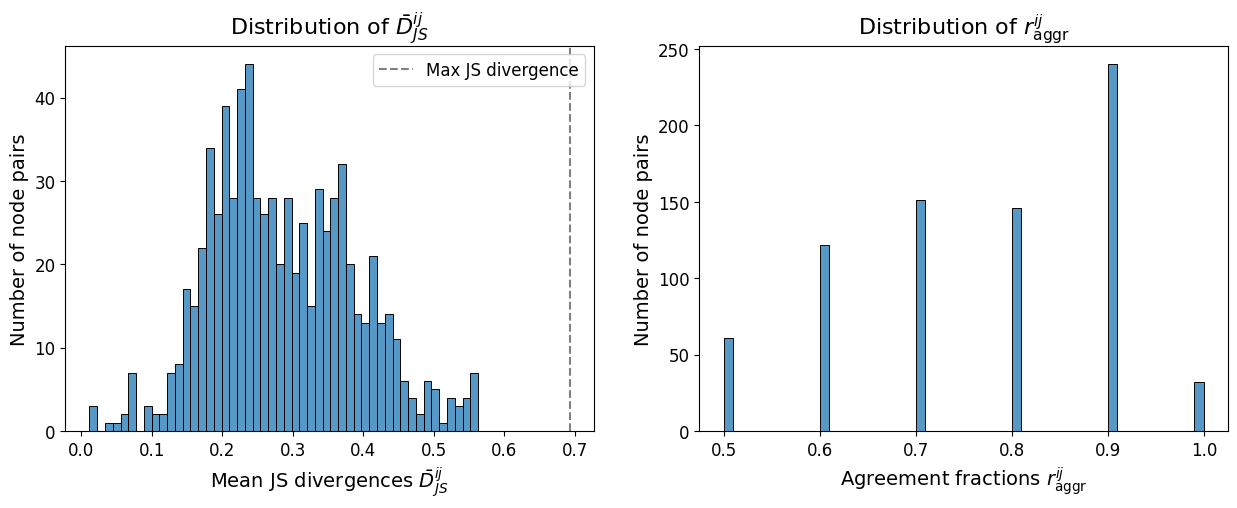

In [113]:
for prefix in prefixes:
    stats = edge_statistics[prefix]
    out_dir = Path(os.path.join(out_base, prefix))
    os.makedirs(out_dir, exist_ok=True)
    # draw
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    # 1. mean pairwise js div
    sns.histplot(stats['js_per_edge'][stacked.max(0)[:, 1] > 0.5], bins=50, ax=axes[0])
    axes[0].set_xlabel(r'$\text{Mean JS divergences } \bar{D}_{JS}^{ij}$')
    axes[0].set_ylabel('Number of node pairs')
    axes[0].set_title(r'$\text{Distribution of } \bar{D}_{JS}^{ij}$')
    axes[0].axvline(0.6931, color='gray', linestyle='--', label='Max JS divergence')
    axes[0].legend(loc='upper right')
    # 2. agreement fraction
    sns.histplot(
        stats['agreement_fraction'][stacked.max(0)[:, 1] > 0.5],
        bins=50,
        ax=axes[1],
        element="bars",
    )
    axes[1].set_xlabel(r'$\text{Agreement fractions } r^{ij}_{\text{aggr}}$')
    axes[1].set_ylabel('Number of node pairs')
    axes[1].set_title(r'$\text{Distribution of } r^{ij}_{\text{aggr}}$')
    fig.savefig(Path(out_dir, "consensus_summary.png"))
    fig.savefig(Path(out_dir, "consensus_summary.svg"))
    plt.show()

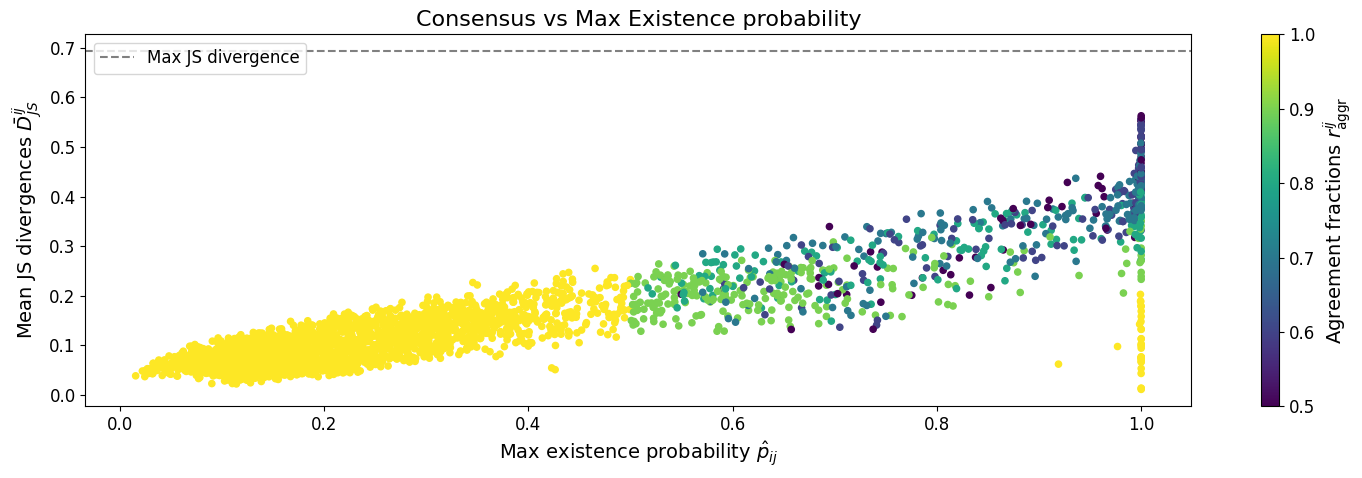

In [114]:
for prefix in prefixes:
    stats = edge_statistics[prefix]
    out_dir = Path(os.path.join(out_base, prefix))
    os.makedirs(out_dir, exist_ok=True)
    # 3. Max Existence probability vs variability (JS-Div)
    fig = plt.figure(figsize=(15, 5))
    sc = plt.scatter(stats['max_exists_probs'], stats['js_per_edge'], c=stats['agreement_fraction'], cmap="viridis", s=20)
    plt.xlabel(r'$\text{Max existence probability } \hat{p}_{ij}$')
    plt.ylabel(r'$\text{Mean JS divergences } \bar{D}_{JS}^{ij}$')
    plt.title('Consensus vs Max Existence probability')
    plt.axhline(0.6931, color='gray', linestyle='--', label='Max JS divergence')
    plt.legend(loc="upper left")
    cbar = plt.colorbar(sc, label=r'$\text{Agreement fractions } r^{ij}_{\text{aggr}}$')
    plt.tight_layout()

    fig.savefig(Path(out_dir, "consensus_vs_existence_prob.png"))
    fig.savefig(Path(out_dir, "consensus_vs_existence_prob.svg"))
    plt.show()

Number of consensus edges: 17


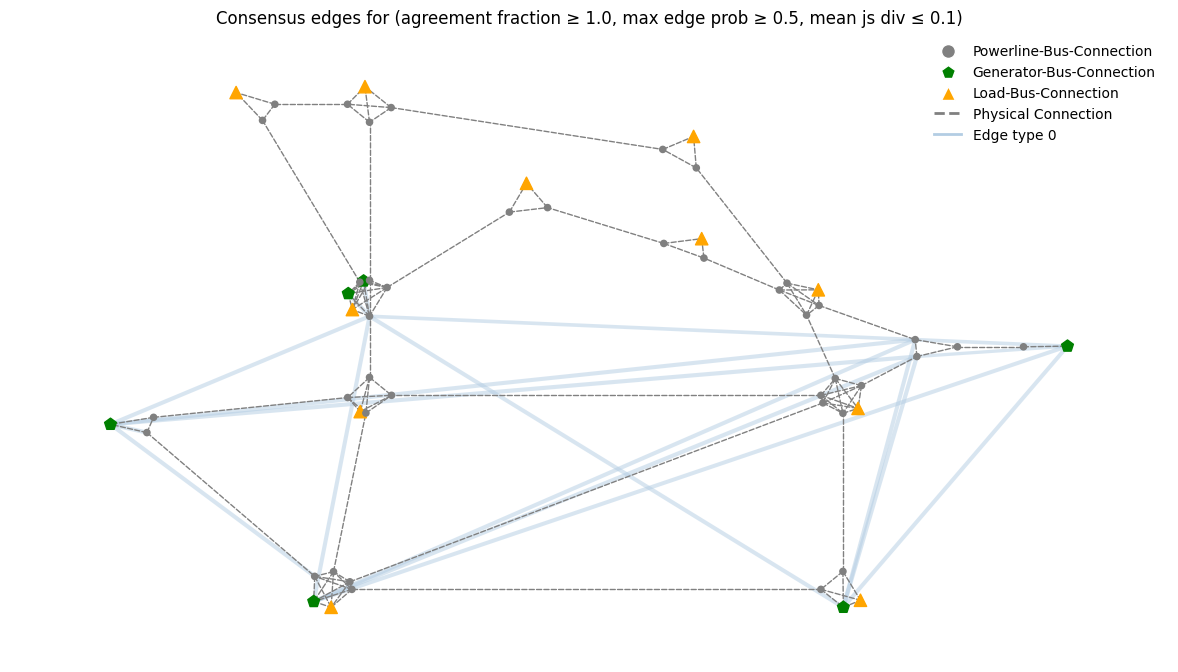

Saved consensus graph to `output/edge_consistency_notebook/edges_testing_NRI_with_forecast/consensus_graph_edges_testing_NRI_with_forecast.png`
Saved consensus graph to `output/edge_consistency_notebook/edges_testing_NRI_with_forecast/consensus_graph_edges_testing_NRI_with_forecast.svg`
Saved consensus graph to `output/edge_consistency_notebook/edges_testing_NRI_with_forecast/consensus_graph_data_edges_testing_NRI_with_forecast_agreement_1_0_prob_0_5_js_0_1.npy`


In [82]:
agreement_threshold = 1.0
probability_threshold = 0.5
js_threshold = 0.1

def consensus_graph(stats: dict, agreement_threshold: float, probability_threshold: float, js_threshold: float) -> np.ndarray:
    """
    Build (E, K) array with nonzero probabilities only for edges surpassing the agreement threshold.
    Keeps the mean probability for the consensus (mode) type; zero elsewhere.
    Optionally ignore edges whose consensus type is 0 (often 'no-edge').

    :param stats: dict containing 'mean_probs' (E, K), 'agreement_fraction' (E,), and js_per_edge (E,)
    :param agreement_threshold: minimum agreement fraction to consider an edge in consensus
    :param probability_threshold: minimum max probability for the consensus type to display the edge
    :param js_threshold: maximum mean JS divergence to consider an edge in consensus (lower means more consistent)
    :return: latent edge probs array of shape (E, K) where consensus edges have their mean probabilities and non-consensus edges are zeroed out.
    """
    E, K = stats['mean_probs'].shape
    mean_probs = stats['mean_probs']  # (E, K)
    agreement_fraction = stats['agreement_fraction']  # (E,)
    out = np.zeros_like(mean_probs)
    relevant_edge_mask = np.logical_and(
        np.logical_and(
            stacked[..., :-1].sum(-1).max(0) >= probability_threshold,
            agreement_fraction >= agreement_threshold
        ),
        stats['js_per_edge'] < js_threshold
    )
    print("Number of consensus edges:", relevant_edge_mask.sum())
    out[relevant_edge_mask] = mean_probs[relevant_edge_mask]
    out[~relevant_edge_mask] = np.repeat(np.concatenate([np.zeros((1, K-1)), np.array([[1]])], axis=1), (~relevant_edge_mask).sum(), 0)
    return out

for prefix in prefixes:
    stacked, files = load_and_stack(data_dir, prefix, no_interaction_index=no_interaction_index)
    S, E, K = stacked.shape
    consensus_latent = consensus_graph(
        edge_statistics[prefix],
        agreement_threshold,
        probability_threshold,
        js_threshold,
    )

    fig = visualize_graph(PlottingArgs(
        num_nodes=N,
        node_styles=get_node_styles(env=env, observation_space=BusConnectivityGraphObsSpace),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=consensus_latent,
        latent_edge_weight=3,
        skip_last_edge_type=True,
    ))


    plt.title(f'Consensus edges for (agreement fraction ≥ {agreement_threshold}, max edge prob ≥ {probability_threshold}, mean js div ≤ {js_threshold})')
    plt.show()
    plt.close(fig)

    # Save the consensus graph
    try:
        save_path = Path(os.path.join(out_base, prefix, f'consensus_graph_{prefix}.png'))
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved consensus graph to `{save_path}`')
        save_path = Path(os.path.join(out_base, prefix, f'consensus_graph_{prefix}.svg'))
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved consensus graph to `{save_path}`')
        # save consensus graph data as npy
        data_save_path = Path(os.path.join(out_base, prefix, f'consensus_graph_data_{prefix}_agreement_{agreement_threshold}_prob_{probability_threshold}_js_{js_threshold}'.replace(".", "_") + ".npy"))
        np.save(data_save_path, consensus_latent)
        print(f'Saved consensus graph to `{data_save_path}`')

    except Exception as ex:
        print('Could not save consensus graph:', ex)
